In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

import sys
sys.path.append('..')

import PyESRSTM

# Time Propagation 

In some cases, long time solution alone is not sufficient, and we need to look at initial conditions. In that case we can propagate the quantum in time by integrationg the QME. This is much more computationally demanding but can give us further insight.

We start by defining a system, with $1+A\cos\omega t$ time dependence of the rates, and looking at the long time solution.  

Hermiticity check passed!


/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


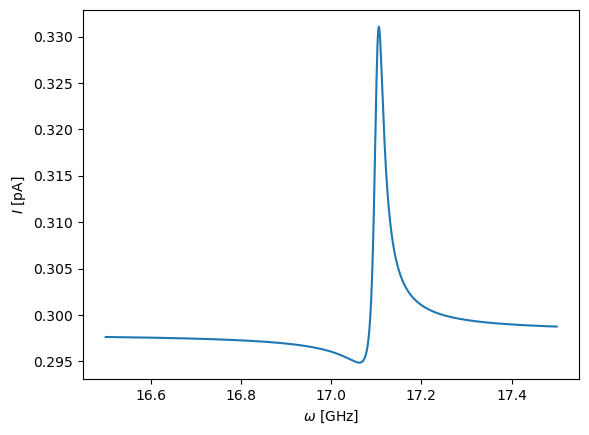

In [2]:
dot = PyESRSTM.QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=.5)

freq_long_time = np.linspace(16.5, 17.5, 1000)
I_long_time = PyESRSTM.ESR.ESR(Left, Right, dot, freq_long_time, NFL=1)
# the returned signal is in the shape (len(freq), 2*NFL+1)

plt.plot(freq_long_time, I_long_time[:, 2])
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()


Next we can calculate the evolution of the system near the resonance frequency, we chose $\omega = 17$ GHz.

`propagete_density` function takes in the rates [Hart], the energy differecnes `dot.Delta` [Hart], frequency [Ghz], and the total time [ns]. The units are a little bit of a mismatch since some of the input values come from other parts of the code, and thus are in atomic units and frequency and time are user defined. 
We also define the initial state of the impurity, in this case it is fully in the ground state. 

In [3]:
GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)

GL = GLplus + GLminus
GR = GRplus + GRminus
GC = GLplus - GLminus

In [4]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1

kwargs = {'max_step': 0.005, 'method': 'RK45'}
time, rhot = PyESRSTM.propagate_density(GL, GR, dot.Delta, rho0, 700, frequency=17.1, kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.


Bellow we plot the results. 
We also calculate the current using `current_in_time` which, takes the array of times, evolution of rho, and GC 
Finally we fit the amplitude, frequency and decay, and quality factor of the Rabi oscillations.

Rabi oscillation: 
  A = 0.496
  Omega = 75.811 [MHz]
  T2 = 36.799 [ns]
  QF = 0.444


/tmp/ipykernel_3662113/3301166.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


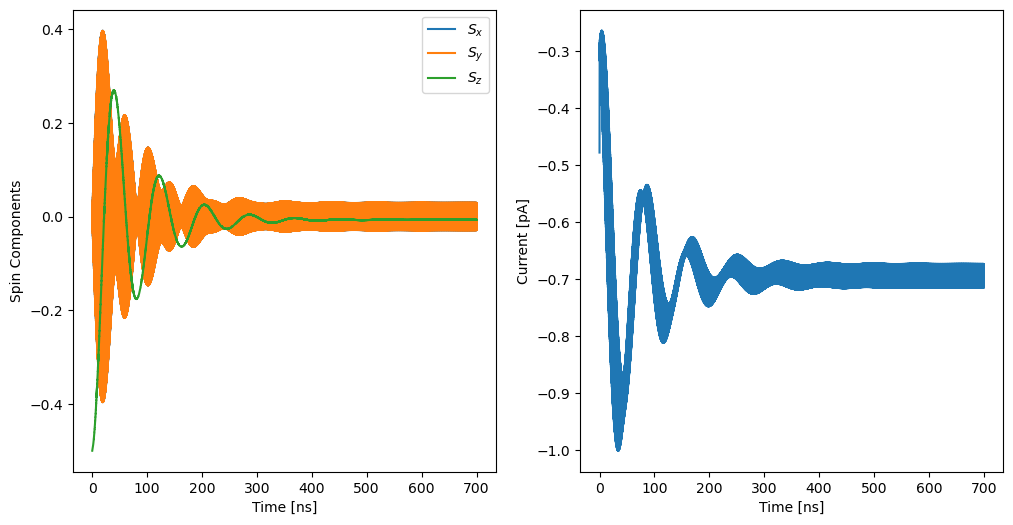

In [ ]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))
ax = ax.flatten()


Sx = 1/2*np.real(rhot[:, 0, 1] + rhot[:, 1, 0])
Sy = 1/2*np.real(1j*(rhot[:, 0,1] - rhot[:, 1,0]))
Sz = 1/2*np.real(rhot[:,1, 1] - rhot[:,0, 0])

I = PyESRSTM.current_in_time(time, rhot, GC, 17.1)


def rabi_oscillation(x, A, omega, T2):
    return A * np.exp(-x/(2*T2)) * np.cos(omega*x)

popt, pcov = curve_fit(rabi_oscillation, time, Sz)

print(f"Rabi oscillation: \n  A = {np.round(np.abs(popt[0]),3)}\n  Omega = {np.round(1000*np.abs(popt[1]),3)} [MHz]\n  T2 = {np.round(popt[2],3)} [ns]\n  QF = {np.round(popt[2]*np.abs(popt[1])/(2*np.pi),3)}")

ax[0].plot(time, Sx, label=r'$S_x$')
ax[0].plot(time, Sy, label=r'$S_y$')
ax[0].plot(time, Sz, label=r'$S_z$')
ax[1].plot(time, I,)

ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Spin Components')
ax[0].legend()
ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Current [pA]')

plt.show()


Likewise we can look at what happens if we initiate the system in a charged, state, and look at the population lifetime $T_1$

Integration successful: True, message: The solver successfully reached the end of the integration interval.
T1 = 0.10735274875207075 [ns]


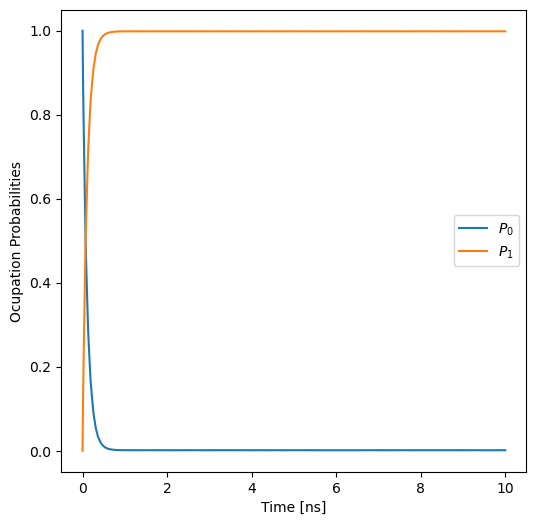

In [6]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[2, 2] = 1

kwargs = {'max_step': 0.005, }
time, rhot = PyESRSTM.propagate_density(GL, GR, dot.Delta, rho0, 10, frequency=17.1, kwargs=kwargs)

def fit_decay(x, T1):
    return np.exp(-x/T1)

popt, pcov = curve_fit(fit_decay, time, np.real(rhot[:, 2,2]))

print(f"T1 = {popt[0]} [ns]") 

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(time, np.real(rhot[:, 2,2]), label=r'$P_{0}$')
ax.plot(time, np.real(rhot[:, 0,0]+rhot[:, 1,1]), label=r'$P_{1}$')


ax.set_xlabel('Time [ns]')
ax.set_ylabel('Ocupation Probabilities')
ax.legend()
plt.show()

In [20]:
MR = PyESRSTM.QME_matrix_propagator(GR, dot.Delta)
ML = PyESRSTM.QME_matrix_propagator(GL[:,:,:,:,1:2], np.zeros_like(dot.Delta))

M = PyESRSTM.QME_matrix_propagator(PyESRSTM.sum_rates(GL, GR), dot.Delta)[:,:,:,:,1:2]

np.max(np.abs((M - MR - ML)/(M+1e-20)))


np.float64(2.1213432378676597e-16)

In [8]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1


kwargs = {'max_step': 0.001, 'method': 'RK45'}
time, rhot = PyESRSTM.propagate_density(GL[:,:,:,:,1:2]*(1.25), GR, dot.Delta, rho0, 300, frequency=np.array([17.1]), adrive=np.array([1/1.25]), kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.


/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


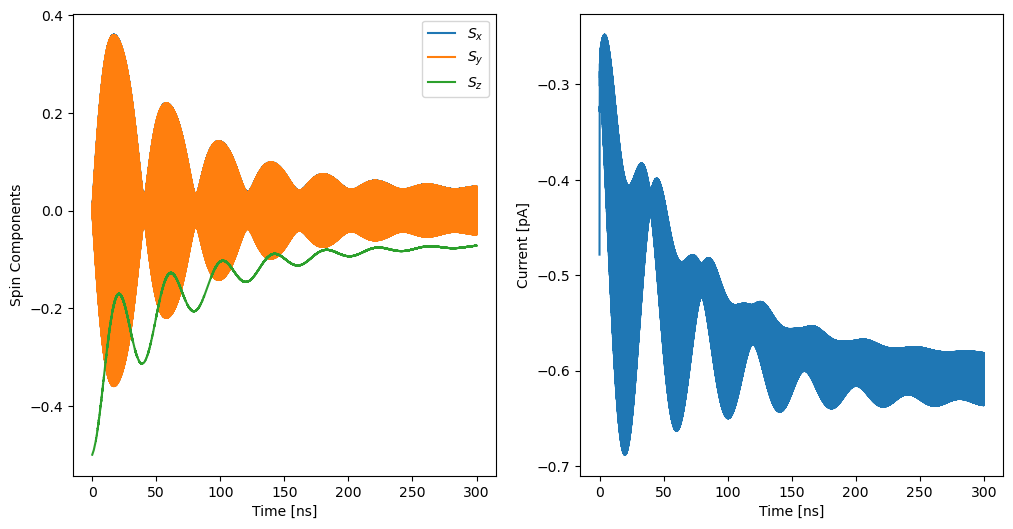

In [9]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))
ax = ax.flatten()


Sx = 1/2*np.real(rhot[:, 0, 1] + rhot[:, 1, 0])
Sy = 1/2*np.real(1j*(rhot[:, 0,1] - rhot[:, 1,0]))
Sz = 1/2*np.real(rhot[:,1, 1] - rhot[:,0, 0])

I = PyESRSTM.current_in_time(time, rhot, GLplus-GLminus, 17.1)

def rabi_oscillation(x, A, omega, T2):
    return A * np.exp(-x/T2) * np.cos(omega*x)

#popt, pcov = curve_fit(rabi_oscillation, time, Sz)

#print(f"Rabi oscillation: \n  A = {np.round(np.abs(popt[0]),3)}\n  Omega = {np.round(1000*np.abs(popt[1]),3)} [MHz]\n  T2 = {np.round(popt[2],3)} [ns]\n  QF = {np.round(popt[2]*np.abs(popt[1])/(2*np.pi),3)}")

ax[0].plot(time, Sx, label=r'$S_x$')
ax[0].plot(time, Sy, label=r'$S_y$')
ax[0].plot(time, Sz, label=r'$S_z$')
ax[1].plot(time, I,)

ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Spin Components')
ax[0].legend()
ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Current [pA]')

plt.show()

In [10]:
As = np.array([.5])
frequencis = np.array([17.1])*2*np.pi*PyESRSTM.units.time_unit
times = np.linspace(0, 3, 1000)/PyESRSTM.units.time_unit
M0 = PyESRSTM.QME_matrix_propagator(G, dot.Delta)[:,:,:,:,0]

phase = np.zeros_like(times)
for i, t in enumerate(times):
    phase[i] = 1+np.sum(As*np.cos(frequencis * t))

plt.plot(times, phase)



NameError: name 'G' is not defined